# Data Cleaning and Merging

This notebook:
1. Cleans `data_for_jasmine.json` (delete benchmarks, relabel evals)
2. Creates a union of `data_for_jasmine_cleaned` and `data68k_cleaned.json`
3. Analyzes the combined dataset

## Cleaning Rules (from CHANGES.md):
- Delete `prosocial_dialog`
- Delete `prism`
- Re-label `hackaprompt_dataset` as eval (set `eval_category=True`)

In [31]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from copy import deepcopy

try:
    import ijson
    USE_IJSON = True
except ImportError:
    USE_IJSON = False
    print("ijson not available, using standard json")

## 1. Load Both Datasets

In [32]:
# Load data_for_jasmine.json
data_jasmine = []

if USE_IJSON:
    with open('./data_for_jasmine.json', 'rb') as f:
        try:
            for record in ijson.items(f, 'item'):
                data_jasmine.append(record)
        except ijson.IncompleteJSONError:
            print(f"File truncated, but recovered {len(data_jasmine)} complete records")
else:
    with open('./data_for_jasmine.json', 'r') as f:
        data_jasmine = json.load(f)

print(f"Total records in data_for_jasmine.json: {len(data_jasmine)}")

Total records in data_for_jasmine.json: 50001


In [33]:
# Load data68k_cleaned.json
data_68k = []

if USE_IJSON:
    with open('./data68k_cleaned.json', 'rb') as f:
        try:
            for record in ijson.items(f, 'item'):
                data_68k.append(record)
        except ijson.IncompleteJSONError:
            print(f"File truncated, but recovered {len(data_68k)} complete records")
else:
    with open('./data68k_cleaned.json', 'r') as f:
        data_68k = json.load(f)

print(f"Total records in data68k_cleaned.json: {len(data_68k)}")

Total records in data68k_cleaned.json: 62166


## 2. Clean data_for_jasmine.json

In [34]:
def clean_data(data):
    """
    Clean the dataset according to CHANGES.md specifications.
    
    Changes:
    1. Delete prosocial_dialog
    2. Delete prism
    3. Re-label hackaprompt_dataset as eval_category=True
    
    Returns:
        cleaned_data: list of cleaned records
        stats: dict with cleaning statistics
    """
    stats = {
        'original_count': len(data),
        'deleted_prosocial_dialog': 0,
        'deleted_prism': 0,
        'relabeled_hackaprompt': 0,
    }
    
    # Benchmarks to delete entirely
    delete_entirely = {'prosocial_dialog', 'prism'}
    
    # Benchmarks to re-label as evaluations
    relabel_as_eval = {'hackaprompt_dataset'}
    
    cleaned_data = []
    
    for item in data:
        item_id = item.get('id', '')
        benchmark = item_id.split(':')[0] if ':' in item_id else item_id
        
        # Skip if benchmark should be deleted entirely
        if benchmark == 'prosocial_dialog':
            stats['deleted_prosocial_dialog'] += 1
            continue
        if benchmark == 'prism':
            stats['deleted_prism'] += 1
            continue
        
        # Make a deep copy to avoid modifying original
        item = deepcopy(item)
        
        # Re-label hackaprompt_dataset as evaluations
        if benchmark in relabel_as_eval:
            if 'metadata' not in item:
                item['metadata'] = {}
            
            if item['metadata'].get('eval_category') != True:
                item['metadata']['eval_category'] = True
                item['metadata']['eval_type'] = 'alignment'
                stats['relabeled_hackaprompt'] += 1
        
        cleaned_data.append(item)
    
    stats['final_count'] = len(cleaned_data)
    stats['total_deleted'] = stats['original_count'] - stats['final_count']
    
    return cleaned_data, stats

In [35]:
# Clean data_for_jasmine
data_jasmine_cleaned, cleaning_stats = clean_data(data_jasmine)

print("=" * 60)
print("CLEANING STATISTICS for data_for_jasmine.json")
print("=" * 60)
print(f"Original count: {cleaning_stats['original_count']}")
print(f"Final count: {cleaning_stats['final_count']}")
print(f"Total deleted: {cleaning_stats['total_deleted']}")
print()
print("Breakdown:")
print(f"  Deleted prosocial_dialog: {cleaning_stats['deleted_prosocial_dialog']}")
print(f"  Deleted prism: {cleaning_stats['deleted_prism']}")
print(f"  Re-labeled hackaprompt_dataset: {cleaning_stats['relabeled_hackaprompt']}")

CLEANING STATISTICS for data_for_jasmine.json
Original count: 50001
Final count: 47301
Total deleted: 2700

Breakdown:
  Deleted prosocial_dialog: 1350
  Deleted prism: 1350
  Re-labeled hackaprompt_dataset: 1350


In [36]:
# Verify cleaning
print("\nVerification - Benchmarks in cleaned data:")
cleaned_benchmarks = Counter()
for item in data_jasmine_cleaned:
    item_id = item.get('id', '')
    benchmark = item_id.split(':')[0] if ':' in item_id else item_id
    cleaned_benchmarks[benchmark] += 1

print(f"\nTotal unique benchmarks: {len(cleaned_benchmarks)}")

# Verify deletions
print("\nDeleted benchmarks (should be 0):")
print(f"  prosocial_dialog: {cleaned_benchmarks.get('prosocial_dialog', 0)}")
print(f"  prism: {cleaned_benchmarks.get('prism', 0)}")

# Verify re-labeling
print("\nHackaprompt_dataset eval_category values:")
hackaprompt_samples = [item for item in data_jasmine_cleaned if item.get('id', '').startswith('hackaprompt_dataset')]
if hackaprompt_samples:
    eval_cats = Counter(item.get('metadata', {}).get('eval_category') for item in hackaprompt_samples)
    print(f"  {dict(eval_cats)}")
else:
    print("  (no hackaprompt_dataset samples in this dataset)")


Verification - Benchmarks in cleaned data:

Total unique benchmarks: 58

Deleted benchmarks (should be 0):
  prosocial_dialog: 0
  prism: 0

Hackaprompt_dataset eval_category values:
  {True: 1350}


## 3. Create Union of Datasets (No Duplicates)

In [37]:
# First, check overlap
jasmine_ids = set(item.get('id', '') for item in data_jasmine_cleaned)
cleaned_68k_ids = set(item.get('id', '') for item in data_68k)

overlap_ids = jasmine_ids & cleaned_68k_ids
jasmine_only_ids = jasmine_ids - cleaned_68k_ids
cleaned_68k_only_ids = cleaned_68k_ids - jasmine_ids

print("=" * 60)
print("OVERLAP ANALYSIS")
print("=" * 60)
print(f"Records in data_for_jasmine_cleaned: {len(jasmine_ids)}")
print(f"Records in data68k_cleaned: {len(cleaned_68k_ids)}")
print(f"\nOverlapping records: {len(overlap_ids)}")
print(f"Unique to data_for_jasmine_cleaned: {len(jasmine_only_ids)}")
print(f"Unique to data68k_cleaned: {len(cleaned_68k_only_ids)}")
print(f"\nExpected union size: {len(jasmine_only_ids) + len(cleaned_68k_only_ids) + len(overlap_ids)}")

OVERLAP ANALYSIS
Records in data_for_jasmine_cleaned: 47301
Records in data68k_cleaned: 62166

Overlapping records: 18891
Unique to data_for_jasmine_cleaned: 28410
Unique to data68k_cleaned: 43275

Expected union size: 90576


In [38]:
def create_union(data_jasmine_cleaned, data_68k):
    """
    Create a union of both datasets with no duplicates.
    Add a 'source' field to track origin.
    
    For overlapping IDs, we keep the version from data_for_jasmine_cleaned
    (since it might have more metadata fields).
    """
    # Create a dict for fast lookup
    union_dict = {}
    
    # First, add all records from data68k_cleaned
    for item in data_68k:
        item_id = item.get('id', '')
        item_copy = deepcopy(item)
        if 'metadata' not in item_copy:
            item_copy['metadata'] = {}
        item_copy['metadata']['source'] = 'data68k_cleaned'
        union_dict[item_id] = item_copy
    
    # Then, add/overwrite with records from data_for_jasmine_cleaned
    # This ensures jasmine version takes precedence for overlaps
    for item in data_jasmine_cleaned:
        item_id = item.get('id', '')
        item_copy = deepcopy(item)
        if 'metadata' not in item_copy:
            item_copy['metadata'] = {}
        
        # Mark source - if it was in both, note that
        if item_id in union_dict:
            item_copy['metadata']['source'] = 'data_for_jasmine_cleaned'  # from jasmine (also in 68k)
        else:
            item_copy['metadata']['source'] = 'data_for_jasmine_cleaned'
        
        union_dict[item_id] = item_copy
    
    return list(union_dict.values())

In [39]:
# Create the union
data_combined = create_union(data_jasmine_cleaned, data_68k)

print("=" * 60)
print("COMBINED DATASET")
print("=" * 60)
print(f"Total records in combined dataset: {len(data_combined)}")

# Verify source distribution
source_counts = Counter(item.get('metadata', {}).get('source') for item in data_combined)
print(f"\nSource distribution:")
for source, count in source_counts.items():
    print(f"  {source}: {count}")

COMBINED DATASET
Total records in combined dataset: 90576

Source distribution:
  data_for_jasmine_cleaned: 47301
  data68k_cleaned: 43275


In [40]:
# Verify no duplicates
combined_ids = [item.get('id', '') for item in data_combined]
id_counts = Counter(combined_ids)
duplicates = {id_: count for id_, count in id_counts.items() if count > 1}

print(f"\nDuplicate check:")
if duplicates:
    print(f"  WARNING: Found {len(duplicates)} duplicate IDs!")
    for id_, count in list(duplicates.items())[:5]:
        print(f"    {id_}: {count}")
else:
    print(f"  No duplicate IDs found. All {len(data_combined)} records are unique.")


Duplicate check:
  No duplicate IDs found. All 90576 records are unique.


## 4. Save Combined Dataset

In [41]:
# Save the combined dataset
from decimal import Decimal

class DecimalEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, Decimal):
            return float(obj)
        return super().default(obj)

output_path = './data_combined.json'
with open(output_path, 'w') as f:
    json.dump(data_combined, f, indent=2, cls=DecimalEncoder)

print(f"Saved combined dataset to {output_path}")
print(f"Total records: {len(data_combined)}")

Saved combined dataset to ./data_combined.json
Total records: 90576


In [42]:
# Also save the cleaned jasmine data separately
jasmine_output_path = './data_for_jasmine_cleaned.json'
with open(jasmine_output_path, 'w') as f:
    json.dump(data_jasmine_cleaned, f, indent=2, cls=DecimalEncoder)

print(f"Saved cleaned jasmine data to {jasmine_output_path}")
print(f"Total records: {len(data_jasmine_cleaned)}")

Saved cleaned jasmine data to ./data_for_jasmine_cleaned.json
Total records: 47301


---

# Analysis of Combined Dataset

In [43]:
# Create DataFrame for analysis
records = []
for item in data_combined:
    record_id = item.get('id', '')
    metadata = item.get('metadata', {})
    input_msgs = item.get('input', [])
    
    # Extract benchmark name from id
    benchmark = record_id.split(':')[0] if ':' in record_id else record_id
    
    records.append({
        'id': record_id,
        'benchmark': benchmark,
        'source': metadata.get('source', 'unknown'),
        'category': metadata.get('category', ''),
        'subcategory': metadata.get('subcategory', ''),
        'scaffold': metadata.get('scaffold'),
        'eval_category': metadata.get('eval_category'),
        'eval_type': metadata.get('eval_type', ''),
        'num_messages': len(input_msgs),
        'has_tools': len(metadata.get('tools', [])) > 0
    })

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (90576, 10)


,id,benchmark,source,category,subcategory,scaffold,eval_category,eval_type,num_messages,has_tools
0,toxic_chat:83fef27ec99b31c277f18a041a217486bfe...,toxic_chat,data_for_jasmine_cleaned,toxic_chat,toxicchat0124,None,False,,2,False
1,safetybench:en:7777,safetybench,data68k_cleaned,safetybench,illegal_activities,None,True,alignment,2,False
2,cvalues_rlhf:3905,cvalues_rlhf,data_for_jasmine_cleaned,cvalues_rlhf,None,None,True,,2,False
3,gest:2427,gest,data68k_cleaned,gest,None,None,True,alignment,2,False
4,cvalues_rlhf:41231,cvalues_rlhf,data68k_cleaned,cvalues_rlhf,None,None,True,alignment,2,False


## 5. Source Distribution Analysis

Source Distribution:
source
data_for_jasmine_cleaned    47301
data68k_cleaned             43275
Name: count, dtype: int64

Total: 90576


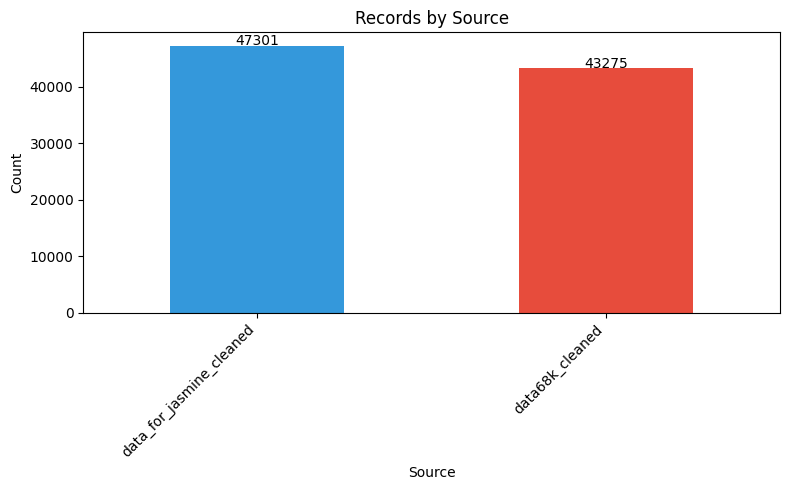

In [44]:
# Source distribution
source_counts = df['source'].value_counts()
print("Source Distribution:")
print(source_counts)
print(f"\nTotal: {source_counts.sum()}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
source_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('Records by Source')
ax.set_xlabel('Source')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(source_counts):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

## 6. Conversation Style: Agentic vs Chat

In [45]:
# Conversation style breakdown
df['conversation_style'] = df['scaffold'].apply(lambda x: 'Agentic' if x is not None else 'Chat')

style_counts = df['conversation_style'].value_counts()
print("Conversation Style Breakdown:")
print(style_counts)
print(f"\nTotal: {style_counts.sum()}")

Conversation Style Breakdown:
conversation_style
Chat       87869
Agentic     2707
Name: count, dtype: int64

Total: 90576


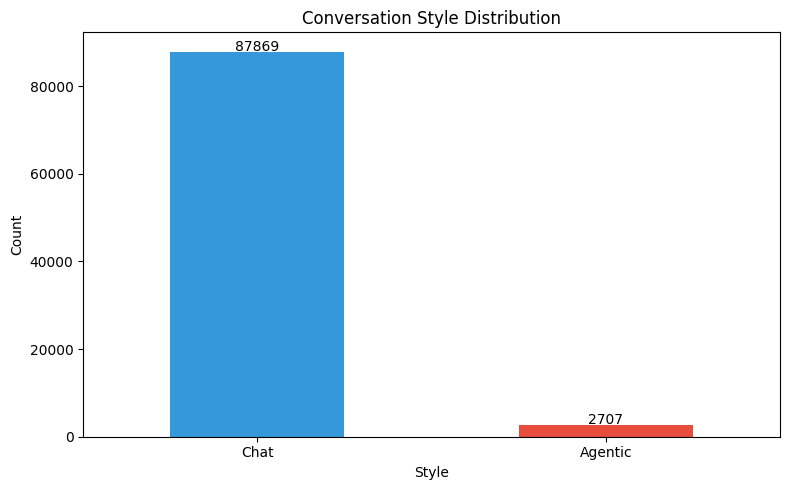

In [46]:
# Visualize conversation style
fig, ax = plt.subplots(figsize=(8, 5))
style_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('Conversation Style Distribution')
ax.set_xlabel('Style')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(style_counts):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

In [61]:
# Show benchmarks for "Eval (type: unspecified)"
unspecified_evals = df[(df['eval_category'] == True) & ((df['eval_type'] == '') | (df['eval_type'].isna()))]
print(f"Records with eval_category=True but unspecified eval_type: {len(unspecified_evals)}")
print(f"\nDistinct benchmarks ({len(unspecified_evals['benchmark'].unique())}):")
for bench in sorted(unspecified_evals['benchmark'].unique()):
    count = (unspecified_evals['benchmark'] == bench).sum()
    print(f"  {bench}: {count}")

Records with eval_category=True but unspecified eval_type: 34669

Distinct benchmarks (37):
  agentharm: 175
  aya_redteaming: 1349
  categoricalharmfulqa: 550
  civics: 700
  cvalues_rlhf: 1349
  cybench: 40
  discrim_eval: 1350
  do_not_answer: 939
  ethics_commonsense: 1349
  ethics_deontology: 1349
  ethics_justice: 1349
  ethics_utilitarianism: 1349
  ethics_virtue: 1349
  gest: 1350
  govind_runs: 6
  harmfulqa: 1349
  honeypot: 19
  kobbq: 1350
  llm_global_opinions: 1349
  mmlu: 1350
  model_written_evals: 1349
  moralexceptqa: 148
  mvp: 7
  natural_reasoning: 1350
  nl2bash: 1350
  or_bench: 1349
  real_toxicity_prompts: 1350
  s_eval: 1349
  safetybench: 1349
  simplesafetytests: 80
  smol_gaia_manager: 60
  smol_gaia_search: 39
  swe_gym: 1350
  swebench: 497
  ultrasafety: 1349
  wmdp: 1273
  xstest_v2_copy: 450


In [62]:
# Check for null eval_category values
null_eval_cat = df[df['eval_category'].isna()]
print(f"Records with null eval_category: {len(null_eval_cat)}")

if len(null_eval_cat) > 0:
    print(f"\nDistinct benchmarks with null eval_category ({len(null_eval_cat['benchmark'].unique())}):")
    for bench in sorted(null_eval_cat['benchmark'].unique()):
        count = (null_eval_cat['benchmark'] == bench).sum()
        print(f"  {bench}: {count}")
    
    print(f"\nBy source:")
    print(null_eval_cat['source'].value_counts())

Records with null eval_category: 0


In [64]:
# Count data points for specific benchmark names
target_benchmarks = [
    'aya_redteaming',
    'categoricalharmfulqa',
    'civics',
    'cvalues_rlhf',
    'discrim_eval',
    'do_not_answer',
    'ethics',
    'gandalf_ignore_instructions',
    'gandalf_summarization',
    'gest',
    'harmfulqa',
    'kobbq',
    'llm_global_opinions',
    'mmlu',
    'model_written_evals',
    'moralexceptqa',
    'mosscap_prompt_injection',
    'natural_reasoning',
    'nl2bash',
    'or_bench',
    'real_toxicity_prompts',
    's_eval',
    'safetybench',
    'simplesafetytests',
    'ultrasafety',
    'wmdp',
    'xstest_v2_copy',
]

print(f"Counts for {len(target_benchmarks)} target benchmarks:")
print("=" * 50)

total_count = 0
found_benchmarks = []
missing_benchmarks = []

for bench in target_benchmarks:
    count = (df['benchmark'] == bench).sum()
    total_count += count
    if count > 0:
        found_benchmarks.append((bench, count))
        print(f"  {bench}: {count}")
    else:
        missing_benchmarks.append(bench)

print("=" * 50)
print(f"\nTotal data points from target benchmarks: {total_count}")
print(f"Benchmarks found: {len(found_benchmarks)}/{len(target_benchmarks)}")

if missing_benchmarks:
    print(f"\nMissing benchmarks ({len(missing_benchmarks)}):")
    for bench in missing_benchmarks:
        print(f"  - {bench}")

Counts for 27 target benchmarks:
  aya_redteaming: 2501
  categoricalharmfulqa: 550
  civics: 700
  cvalues_rlhf: 3219
  discrim_eval: 3088
  do_not_answer: 939
  ethics: 2000
  gandalf_ignore_instructions: 777
  gandalf_summarization: 114
  gest: 2487
  harmfulqa: 1924
  kobbq: 2313
  llm_global_opinions: 2186
  mmlu: 2072
  model_written_evals: 3005
  moralexceptqa: 148
  mosscap_prompt_injection: 2802
  natural_reasoning: 3292
  nl2bash: 2927
  or_bench: 2396
  real_toxicity_prompts: 2467
  s_eval: 3349
  safetybench: 3349
  simplesafetytests: 80
  ultrasafety: 2282
  wmdp: 2108
  xstest_v2_copy: 450

Total data points from target benchmarks: 53525
Benchmarks found: 27/27


In [65]:
# Check for target benchmarks with no eval_type
target_df = df[df['benchmark'].isin(target_benchmarks)]
no_eval_type = target_df[(target_df['eval_type'] == '') | (target_df['eval_type'].isna())]

print(f"Target benchmark data points with no eval_type: {len(no_eval_type)} / {len(target_df)}")

if len(no_eval_type) > 0:
    print(f"\nBreakdown by benchmark:")
    for bench in sorted(no_eval_type['benchmark'].unique()):
        count = (no_eval_type['benchmark'] == bench).sum()
        total = (target_df['benchmark'] == bench).sum()
        print(f"  {bench}: {count}/{total} missing eval_type")
    
    print(f"\neval_category values for these records:")
    print(no_eval_type['eval_category'].value_counts(dropna=False))

Target benchmark data points with no eval_type: 29972 / 53525

Breakdown by benchmark:
  aya_redteaming: 1349/2501 missing eval_type
  categoricalharmfulqa: 550/550 missing eval_type
  civics: 700/700 missing eval_type
  cvalues_rlhf: 1349/3219 missing eval_type
  discrim_eval: 1350/3088 missing eval_type
  do_not_answer: 939/939 missing eval_type
  ethics: 2000/2000 missing eval_type
  gandalf_ignore_instructions: 777/777 missing eval_type
  gandalf_summarization: 114/114 missing eval_type
  gest: 1350/2487 missing eval_type
  harmfulqa: 1349/1924 missing eval_type
  kobbq: 1350/2313 missing eval_type
  llm_global_opinions: 1349/2186 missing eval_type
  mmlu: 1350/2072 missing eval_type
  model_written_evals: 1349/3005 missing eval_type
  moralexceptqa: 148/148 missing eval_type
  mosscap_prompt_injection: 1350/2802 missing eval_type
  natural_reasoning: 1350/3292 missing eval_type
  nl2bash: 1350/2927 missing eval_type
  or_bench: 1349/2396 missing eval_type
  real_toxicity_prompts: 

In [67]:
# Define the correct classification by benchmark name
alignment_benchmarks = {
    'aya_redteaming', 'categoricalharmfulqa', 'civics', 'cvalues_rlhf', 'discrim_eval',
    'do_not_answer', 'ethics', 'gandalf_ignore_instructions', 'gandalf_summarization',
    'gest', 'harmfulqa', 'kobbq', 'llm_global_opinions', 'model_written_evals',
    'moralexceptqa', 'mosscap_prompt_injection', 'or_bench', 'real_toxicity_prompts',
    's_eval', 'safetybench', 'simplesafetytests', 'ultrasafety', 'xstest_v2_copy'
}

capability_benchmarks = {'mmlu', 'natural_reasoning', 'nl2bash', 'wmdp'}

print("=" * 70)
print("EVAL TYPE CLASSIFICATION ANALYSIS")
print("=" * 70)

# 1. Check unspecified eval_type that can be classified
unspecified = df[(df['eval_category'] == True) & ((df['eval_type'] == '') | (df['eval_type'].isna()))]
print(f"\n1. UNSPECIFIED EVAL_TYPE (eval_category=True, no eval_type): {len(unspecified)}")

unspec_can_classify_alignment = unspecified[unspecified['benchmark'].isin(alignment_benchmarks)]
unspec_can_classify_capability = unspecified[unspecified['benchmark'].isin(capability_benchmarks)]
unspec_unknown = unspecified[~unspecified['benchmark'].isin(alignment_benchmarks | capability_benchmarks)]

print(f"\n   Can classify as ALIGNMENT: {len(unspec_can_classify_alignment)}")
for bench in sorted(unspec_can_classify_alignment['benchmark'].unique()):
    count = (unspec_can_classify_alignment['benchmark'] == bench).sum()
    print(f"     {bench}: {count}")

print(f"\n   Can classify as CAPABILITY: {len(unspec_can_classify_capability)}")
for bench in sorted(unspec_can_classify_capability['benchmark'].unique()):
    count = (unspec_can_classify_capability['benchmark'] == bench).sum()
    print(f"     {bench}: {count}")

print(f"\n   UNKNOWN (not in either list): {len(unspec_unknown)}")
for bench in sorted(unspec_unknown['benchmark'].unique()):
    count = (unspec_unknown['benchmark'] == bench).sum()
    print(f"     {bench}: {count}")

# 2. Check for misclassified alignment evals
print(f"\n" + "=" * 70)
print("2. POTENTIAL MISCLASSIFICATIONS")
print("=" * 70)

# Currently labeled as alignment but should be capability
alignment_labeled = df[df['eval_type'] == 'alignment']
misclass_align_to_cap = alignment_labeled[alignment_labeled['benchmark'].isin(capability_benchmarks)]
print(f"\n   Labeled ALIGNMENT but benchmark is CAPABILITY: {len(misclass_align_to_cap)}")
if len(misclass_align_to_cap) > 0:
    for bench in sorted(misclass_align_to_cap['benchmark'].unique()):
        count = (misclass_align_to_cap['benchmark'] == bench).sum()
        print(f"     {bench}: {count}")

# Currently labeled as capability but should be alignment
capability_labeled = df[df['eval_type'] == 'capability']
misclass_cap_to_align = capability_labeled[capability_labeled['benchmark'].isin(alignment_benchmarks)]
print(f"\n   Labeled CAPABILITY but benchmark is ALIGNMENT: {len(misclass_cap_to_align)}")
if len(misclass_cap_to_align) > 0:
    for bench in sorted(misclass_cap_to_align['benchmark'].unique()):
        count = (misclass_cap_to_align['benchmark'] == bench).sum()
        print(f"     {bench}: {count}")

# 3. Summary
print(f"\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"   Unspecified that can be fixed: {len(unspec_can_classify_alignment) + len(unspec_can_classify_capability)}")
print(f"   Misclassified that need fixing: {len(misclass_align_to_cap) + len(misclass_cap_to_align)}")
print(f"   Unknown benchmarks (need manual review): {len(unspec_unknown)}")

EVAL TYPE CLASSIFICATION ANALYSIS

1. UNSPECIFIED EVAL_TYPE (eval_category=True, no eval_type): 34669

   Can classify as ALIGNMENT: 20408
     aya_redteaming: 1349
     categoricalharmfulqa: 550
     civics: 700
     cvalues_rlhf: 1349
     discrim_eval: 1350
     do_not_answer: 939
     gest: 1350
     harmfulqa: 1349
     kobbq: 1350
     llm_global_opinions: 1349
     model_written_evals: 1349
     moralexceptqa: 148
     or_bench: 1349
     real_toxicity_prompts: 1350
     s_eval: 1349
     safetybench: 1349
     simplesafetytests: 80
     ultrasafety: 1349
     xstest_v2_copy: 450

   Can classify as CAPABILITY: 5323
     mmlu: 1350
     natural_reasoning: 1350
     nl2bash: 1350
     wmdp: 1273

   UNKNOWN (not in either list): 8938
     agentharm: 175
     cybench: 40
     ethics_commonsense: 1349
     ethics_deontology: 1349
     ethics_justice: 1349
     ethics_utilitarianism: 1349
     ethics_virtue: 1349
     govind_runs: 6
     honeypot: 19
     mvp: 7
     smol_gaia_manag

In [66]:
# Save subset: Chat conversation style AND eval (not non-eval)
chat_eval_mask = (df['conversation_style'] == 'Chat') & (df['eval_classification'] != 'Non-eval')
chat_eval_ids = set(df[chat_eval_mask]['id'])

# Filter the original data_combined to get full records
chat_eval_subset = [item for item in data_combined if item.get('id', '') in chat_eval_ids]

print(f"Chat + Eval subset: {len(chat_eval_subset)} records")
print(f"\nBreakdown by eval_classification:")
subset_df = df[chat_eval_mask]
print(subset_df['eval_classification'].value_counts())

print(f"\nBreakdown by benchmark:")
for bench, count in subset_df['benchmark'].value_counts().items():
    print(f"  {bench}: {count}")

# Save to file
output_path = './data_combined_chat_eval_subset.json'
with open(output_path, 'w') as f:
    json.dump(chat_eval_subset, f, indent=2, cls=DecimalEncoder)

print(f"\nSaved to {output_path}")

Chat + Eval subset: 59537 records

Breakdown by eval_classification:
eval_classification
Eval (type: unspecified)    32495
Alignment eval              21966
Capability eval              5076
Name: count, dtype: int64

Breakdown by benchmark:
  hackaprompt_dataset: 3489
  safetybench: 3349
  s_eval: 3349
  natural_reasoning: 3292
  cvalues_rlhf: 3219
  discrim_eval: 3088
  model_written_evals: 3005
  nl2bash: 2927
  aya_redteaming: 2501
  gest: 2487
  real_toxicity_prompts: 2467
  or_bench: 2396
  kobbq: 2313
  ultrasafety: 2282
  llm_global_opinions: 2186
  wmdp: 2108
  mmlu: 2072
  harmfulqa: 1924
  mosscap_prompt_injection: 1452
  ethics_virtue: 1349
  ethics_justice: 1349
  ethics_commonsense: 1349
  ethics_utilitarianism: 1349
  ethics_deontology: 1349
  do_not_answer: 939
  civics: 700
  categoricalharmfulqa: 550
  xstest_v2_copy: 450
  moralexceptqa: 148
  simplesafetytests: 80
  honeypot: 19

Saved to ./data_combined_chat_eval_subset.json


In [68]:
# Additional cleaning: classify ethics_* and honeypot as alignment, remove unwanted benchmarks

# Benchmarks to remove
remove_benchmarks = {
    'agentharm', 'cybench', 'swe_gym', 'swebench', 
    'smol_gaia_manager', 'smol_gaia_search', 'mvp', 'govind_runs'
}

# Additional alignment benchmarks (ethics_* and honeypot)
additional_alignment = {
    'ethics_commonsense', 'ethics_deontology', 'ethics_justice', 
    'ethics_utilitarianism', 'ethics_virtue', 'honeypot'
}

# Update the full alignment set
alignment_benchmarks_full = alignment_benchmarks | additional_alignment

print("=" * 70)
print("ADDITIONAL DATA CLEANING")
print("=" * 70)

# Count what will be removed
remove_count = sum(1 for item in data_combined 
                   if item.get('id', '').split(':')[0] in remove_benchmarks)
print(f"\nRecords to remove: {remove_count}")
for bench in remove_benchmarks:
    count = sum(1 for item in data_combined if item.get('id', '').split(':')[0] == bench)
    if count > 0:
        print(f"  {bench}: {count}")

# Count what will be reclassified
reclassify_count = 0
for item in data_combined:
    benchmark = item.get('id', '').split(':')[0]
    if benchmark in additional_alignment:
        metadata = item.get('metadata', {})
        if metadata.get('eval_type', '') != 'alignment':
            reclassify_count += 1

print(f"\nRecords to classify as alignment: {reclassify_count}")
for bench in additional_alignment:
    count = sum(1 for item in data_combined if item.get('id', '').split(':')[0] == bench)
    if count > 0:
        print(f"  {bench}: {count}")

ADDITIONAL DATA CLEANING

Records to remove: 2174
  swebench: 497
  swe_gym: 1350
  smol_gaia_manager: 60
  govind_runs: 6
  smol_gaia_search: 39
  cybench: 40
  mvp: 7
  agentharm: 175

Records to classify as alignment: 6764
  ethics_virtue: 1349
  ethics_deontology: 1349
  ethics_justice: 1349
  honeypot: 19
  ethics_commonsense: 1349
  ethics_utilitarianism: 1349


In [69]:
# Apply the cleaning and save

data_combined_v2 = []
stats = {
    'removed': 0,
    'classified_alignment': 0,
    'classified_capability': 0,
    'kept': 0
}

for item in data_combined:
    item_id = item.get('id', '')
    benchmark = item_id.split(':')[0] if ':' in item_id else item_id
    
    # Skip benchmarks to remove
    if benchmark in remove_benchmarks:
        stats['removed'] += 1
        continue
    
    # Make a copy
    item = deepcopy(item)
    
    # Classify alignment benchmarks (including new ones)
    if benchmark in alignment_benchmarks_full:
        if 'metadata' not in item:
            item['metadata'] = {}
        if item['metadata'].get('eval_type', '') != 'alignment':
            item['metadata']['eval_type'] = 'alignment'
            item['metadata']['eval_category'] = True
            stats['classified_alignment'] += 1
    
    # Classify capability benchmarks
    elif benchmark in capability_benchmarks:
        if 'metadata' not in item:
            item['metadata'] = {}
        if item['metadata'].get('eval_type', '') != 'capability':
            item['metadata']['eval_type'] = 'capability'
            item['metadata']['eval_category'] = True
            stats['classified_capability'] += 1
    
    stats['kept'] += 1
    data_combined_v2.append(item)

print("=" * 70)
print("CLEANING RESULTS")
print("=" * 70)
print(f"Original count: {len(data_combined)}")
print(f"Removed: {stats['removed']}")
print(f"Classified as alignment: {stats['classified_alignment']}")
print(f"Classified as capability: {stats['classified_capability']}")
print(f"Final count: {len(data_combined_v2)}")

# Update data_combined to use the new version
data_combined = data_combined_v2

CLEANING RESULTS
Original count: 90576
Removed: 2174
Classified as alignment: 31413
Classified as capability: 5323
Final count: 88402


In [70]:
# Save the updated combined dataset
output_path = './data_combined.json'
with open(output_path, 'w') as f:
    json.dump(data_combined, f, indent=2, cls=DecimalEncoder)

print(f"Saved updated data_combined.json")
print(f"Total records: {len(data_combined)}")

# Verify the changes
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

# Check removed benchmarks
for bench in remove_benchmarks:
    count = sum(1 for item in data_combined if item.get('id', '').split(':')[0] == bench)
    print(f"  {bench}: {count} (should be 0)")

# Check eval_type distribution
eval_types = Counter(item.get('metadata', {}).get('eval_type', '') for item in data_combined)
print(f"\neval_type distribution:")
for eval_type, count in eval_types.most_common():
    print(f"  '{eval_type}': {count}")

Saved updated data_combined.json
Total records: 88402

VERIFICATION
  swebench: 0 (should be 0)
  swe_gym: 0 (should be 0)
  smol_gaia_manager: 0 (should be 0)
  govind_runs: 0 (should be 0)
  smol_gaia_search: 0 (should be 0)
  cybench: 0 (should be 0)
  mvp: 0 (should be 0)
  agentharm: 0 (should be 0)

eval_type distribution:
  'alignment': 53379
  '': 24624
  'capability': 10399


In [ ]:
# Regenerate the DataFrame with updated data
records = []
for item in data_combined:
    record_id = item.get('id', '')
    metadata = item.get('metadata', {})
    input_msgs = item.get('input', [])
    
    benchmark = record_id.split(':')[0] if ':' in record_id else record_id
    
    records.append({
        'id': record_id,
        'benchmark': benchmark,
        'source': metadata.get('source', 'unknown'),
        'category': metadata.get('category', ''),
        'subcategory': metadata.get('subcategory', ''),
        'scaffold': metadata.get('scaffold'),
        'eval_category': metadata.get('eval_category'),
        'eval_type': metadata.get('eval_type', ''),
        'num_messages': len(input_msgs),
        'has_tools': len(metadata.get('tools', [])) > 0
    })

df = pd.DataFrame(records)

# Recalculate conversation_style and eval_classification
df['conversation_style'] = df['scaffold'].apply(lambda x: 'Agentic' if x is not None else 'Chat')

def categorize_eval(row):
    if row['eval_category'] != True:
        return 'Non-eval'
    elif row['eval_type'] == 'capability':
        return 'Capability eval'
    elif row['eval_type'] == 'alignment':
        return 'Alignment eval'
    else:
        return f'Eval (type: {row["eval_type"] if row["eval_type"] else "unspecified"})'

df['eval_classification'] = df.apply(categorize_eval, axis=1)

print("Updated DataFrame:")
print(f"  Shape: {df.shape}")
print(f"\neval_classification breakdown:")
print(df['eval_classification'].value_counts())
print(f"\nconversation_style breakdown:")
print(df['conversation_style'].value_counts())

Updated DataFrame:
  Shape: (88402, 12)

eval_classification breakdown:
eval_classification
Alignment eval     53379
Non-eval           24624
Capability eval    10399
Name: count, dtype: int64

conversation_style breakdown:
conversation_style
Chat       87869
Agentic      533
Name: count, dtype: int64


In [73]:
# Check what the 24,624 empty eval_type records are
empty_eval_type = [item for item in data_combined if item.get('metadata', {}).get('eval_type', '') == '']
print(f"Records with empty eval_type: {len(empty_eval_type)}")

# Check their eval_category values
from collections import Counter
eval_cats = Counter(item.get('metadata', {}).get('eval_category') for item in empty_eval_type)
print(f"\neval_category breakdown for empty eval_type:")
for cat, count in eval_cats.items():
    print(f"  {cat}: {count}")

# If any have eval_category=True, show which benchmarks
evals_without_type = [item for item in empty_eval_type if item.get('metadata', {}).get('eval_category') == True]
if evals_without_type:
    print(f"\nWARNING: {len(evals_without_type)} evals still have no eval_type!")
    bench_counts = Counter(item.get('id', '').split(':')[0] for item in evals_without_type)
    for bench, count in bench_counts.most_common():
        print(f"  {bench}: {count}")
else:
    print(f"\nAll {len(empty_eval_type)} records with empty eval_type are Non-evals (eval_category != True). This is expected.")

Records with empty eval_type: 24624

eval_category breakdown for empty eval_type:
  False: 24624

All 24624 records with empty eval_type are Non-evals (eval_category != True). This is expected.


In [72]:
# Re-save the chat_eval_subset with updated data
chat_eval_mask = (df['conversation_style'] == 'Chat') & (df['eval_classification'] != 'Non-eval')
chat_eval_ids = set(df[chat_eval_mask]['id'])

chat_eval_subset = [item for item in data_combined if item.get('id', '') in chat_eval_ids]

print(f"Updated Chat + Eval subset: {len(chat_eval_subset)} records")
print(f"\nBreakdown by eval_classification:")
subset_df = df[chat_eval_mask]
print(subset_df['eval_classification'].value_counts())

# Save to file
output_path = './data_combined_chat_eval_subset.json'
with open(output_path, 'w') as f:
    json.dump(chat_eval_subset, f, indent=2, cls=DecimalEncoder)

print(f"\nSaved to {output_path}")

Updated Chat + Eval subset: 63778 records

Breakdown by eval_classification:
eval_classification
Alignment eval     53379
Capability eval    10399
Name: count, dtype: int64

Saved to ./data_combined_chat_eval_subset.json


In [47]:
# Scaffold types (for agentic samples)
if (df['scaffold'].notna()).any():
    print("Scaffold types:")
    scaffold_counts = df[df['scaffold'].notna()]['scaffold'].value_counts()
    print(scaffold_counts)
else:
    print("No agentic samples (all scaffolds are null)")

Scaffold types:
scaffold
openhands      1360
govind          543
aider           405
smolagents      194
agentharm       175
continue         23
basic_agent       7
Name: count, dtype: int64


In [48]:
# Conversation style by source
style_by_source = pd.crosstab(df['source'], df['conversation_style'])
print("\nConversation Style by Source:")
print(style_by_source)


Conversation Style by Source:
conversation_style        Agentic   Chat
source                                  
data68k_cleaned                 0  43275
data_for_jasmine_cleaned     2707  44594


## 7. Eval Category Breakdown

In [63]:
# Combined breakdown: Non-evals, Capability evals, Alignment evals
def categorize_eval(row):
    if row['eval_category'] != True:
        return 'Non-eval'
    elif row['eval_type'] == 'capability':
        return 'Capability eval'
    elif row['eval_type'] == 'alignment':
        return 'Alignment eval'
    else:
        return f'Eval (type: {row["eval_type"] if row["eval_type"] else "unspecified"})'

df['eval_classification'] = df.apply(categorize_eval, axis=1)
eval_class_counts = df['eval_classification'].value_counts()

print("Eval Classification Breakdown:")
print(eval_class_counts)
print(f"\nTotal: {eval_class_counts.sum()}")

# Print unique benchmark names for alignment evals
alignment_evals = df[df['eval_classification'] == 'Alignment eval']
print(f"\nAlignment eval benchmarks ({len(alignment_evals['benchmark'].unique())} unique):")
for bench in sorted(alignment_evals['benchmark'].unique()):
    count = (alignment_evals['benchmark'] == bench).sum()
    print(f"  {bench}: {count}")


Eval Classification Breakdown:
eval_classification
Eval (type: unspecified)    34669
Non-eval                    28865
Alignment eval              21966
Capability eval              5076
Name: count, dtype: int64

Total: 90576

Alignment eval benchmarks (15 unique):
  aya_redteaming: 1152
  cvalues_rlhf: 1870
  discrim_eval: 1738
  gest: 1137
  hackaprompt_dataset: 3489
  harmfulqa: 575
  kobbq: 963
  llm_global_opinions: 837
  model_written_evals: 1656
  mosscap_prompt_injection: 1452
  or_bench: 1047
  real_toxicity_prompts: 1117
  s_eval: 2000
  safetybench: 2000
  ultrasafety: 933


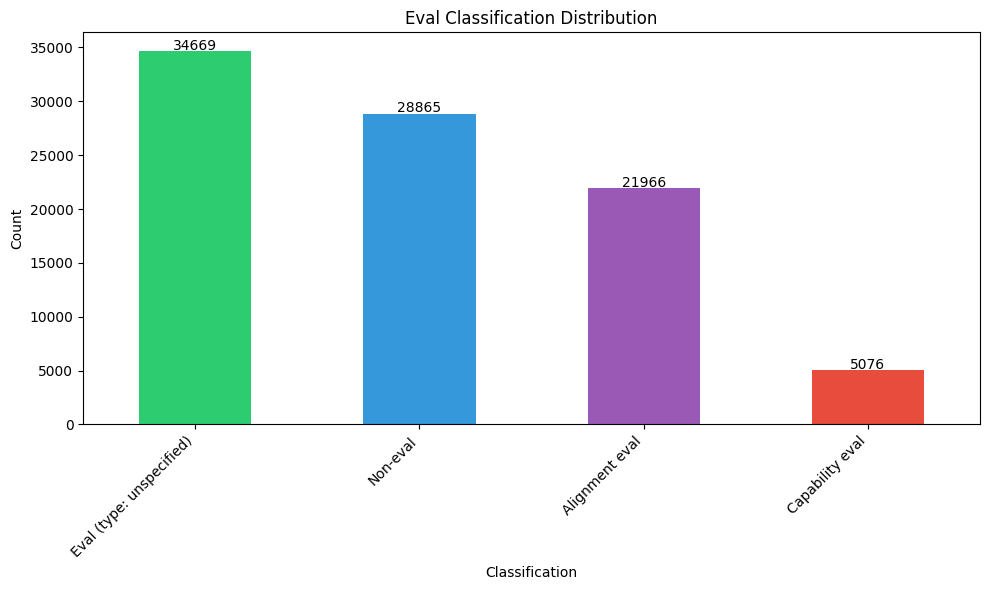

In [50]:
# Visualize eval classification
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
eval_class_counts.plot(kind='bar', ax=ax, color=colors[:len(eval_class_counts)])
ax.set_title('Eval Classification Distribution')
ax.set_xlabel('Classification')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(eval_class_counts):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

In [51]:
# Eval classification by source
eval_by_source = pd.crosstab(df['source'], df['eval_classification'])
print("\nEval Classification by Source:")
print(eval_by_source)


Eval Classification by Source:
eval_classification       Alignment eval  Capability eval  \
source                                                      
data68k_cleaned                    20616             5076   
data_for_jasmine_cleaned            1350                0   

eval_classification       Eval (type: unspecified)  Non-eval  
source                                                        
data68k_cleaned                                  0     17583  
data_for_jasmine_cleaned                     34669     11282  


In [52]:
# eval_category breakdown
print("eval_category breakdown:")
print(df['eval_category'].value_counts(dropna=False))

eval_category breakdown:
eval_category
True     61711
False    28865
Name: count, dtype: int64


In [53]:
# eval_type breakdown
print("eval_type breakdown:")
print(df['eval_type'].value_counts(dropna=False))

eval_type breakdown:
eval_type
              63534
alignment     21966
capability     5076
Name: count, dtype: int64


## 8. Benchmark Breakdown

In [54]:
# Benchmark breakdown
benchmark_counts = df['benchmark'].value_counts()
print(f"Total unique benchmarks: {len(benchmark_counts)}")
print("\nAll benchmarks and counts:")
for name, count in benchmark_counts.items():
    print(f"  {name}: {count}")

Total unique benchmarks: 60

All benchmarks and counts:
  researchy_questions: 4267
  hh_rlhf: 4145
  cdial_bias: 4095
  sharegpt: 3925
  toxigen_data: 3784
  hackaprompt_dataset: 3489
  toxic_chat: 3456
  safetybench: 3349
  s_eval: 3349
  natural_reasoning: 3292
  cvalues_rlhf: 3219
  discrim_eval: 3088
  model_written_evals: 3005
  nl2bash: 2927
  mosscap_prompt_injection: 2802
  aya_redteaming: 2501
  gest: 2487
  real_toxicity_prompts: 2467
  or_bench: 2396
  kobbq: 2313
  ultrasafety: 2282
  llm_global_opinions: 2186
  wmdp: 2108
  mmlu: 2072
  ethics: 2000
  harmfulqa: 1924
  swe_gym: 1350
  ethics_utilitarianism: 1349
  ethics_justice: 1349
  ethics_virtue: 1349
  ethics_deontology: 1349
  ethics_commonsense: 1349
  do_not_answer: 939
  gandalf_ignore_instructions: 777
  civics: 700
  categoricalharmfulqa: 550
  swebench: 497
  xstest_v2_copy: 450
  aider_full: 307
  awesome_chatgpt: 203
  sad_deploy: 200
  agentharm: 175
  moralexceptqa: 148
  gandalf_summarization: 114
  simp

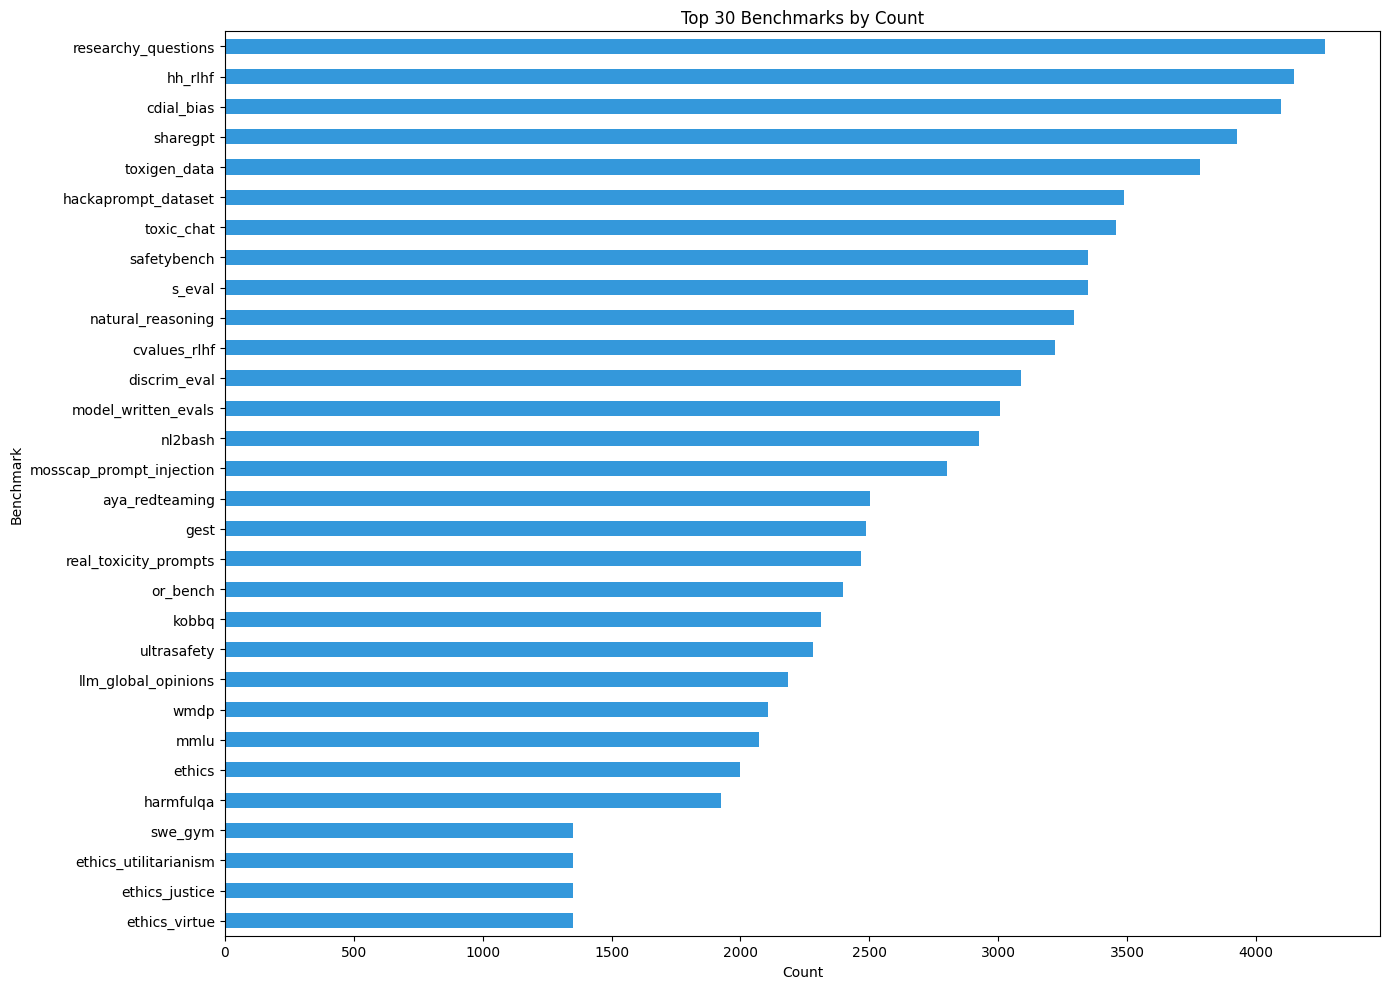

In [55]:
# Visualize benchmark distribution (top 30)
fig, ax = plt.subplots(figsize=(14, 10))
top_benchmarks = benchmark_counts.head(30)
top_benchmarks.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 30 Benchmarks by Count')
ax.set_xlabel('Count')
ax.set_ylabel('Benchmark')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [56]:
# Benchmark by source
benchmark_source = df.groupby(['benchmark', 'source']).size().unstack(fill_value=0)
print("\nBenchmarks by Source:")
print(benchmark_source)


Benchmarks by Source:
source                       data68k_cleaned  data_for_jasmine_cleaned
benchmark                                                             
agentharm                                  0                       175
aider_commit                               0                        60
aider_full                                 0                       307
aider_manual                               0                         4
aider_multi                                0                        34
author_claude                              8                         0
awesome_chatgpt                            0                       203
aya_redteaming                          1152                      1349
categoricalharmfulqa                       0                       550
cdial_bias                              2745                      1350
civics                                     0                       700
continue_dev                               0          

In [57]:
# Summary table
summary_df = df.groupby('benchmark').agg({
    'id': 'count',
    'eval_category': lambda x: (x == True).sum(),
    'conversation_style': lambda x: (x == 'Agentic').sum()
}).rename(columns={
    'id': 'total_count',
    'eval_category': 'eval_count',
    'conversation_style': 'agentic_count'
})
summary_df['non_eval_count'] = summary_df['total_count'] - summary_df['eval_count']
summary_df['chat_count'] = summary_df['total_count'] - summary_df['agentic_count']
summary_df = summary_df.sort_values('total_count', ascending=False)

print("\nBenchmark Summary:")
print(summary_df)


Benchmark Summary:
                             total_count  eval_count  agentic_count  \
benchmark                                                             
researchy_questions                 4267           0              0   
hh_rlhf                             4145           0              0   
cdial_bias                          4095           0              0   
sharegpt                            3925           0              0   
toxigen_data                        3784           0              0   
hackaprompt_dataset                 3489        3489              0   
toxic_chat                          3456           0              0   
s_eval                              3349        3349              0   
safetybench                         3349        3349              0   
natural_reasoning                   3292        3292              0   
cvalues_rlhf                        3219        3219              0   
discrim_eval                        3088        3088     

## 9. Overall Summary

In [58]:
print("=" * 70)
print("OVERALL SUMMARY")
print("=" * 70)

print(f"\n1. DATASET SIZES")
print(f"   data_for_jasmine.json (original): {len(data_jasmine)}")
print(f"   data_for_jasmine_cleaned: {len(data_jasmine_cleaned)}")
print(f"   data68k_cleaned.json: {len(data_68k)}")
print(f"   Combined dataset: {len(data_combined)}")

print(f"\n2. SOURCE DISTRIBUTION")
for source, count in source_counts.items():
    pct = 100 * count / len(data_combined)
    print(f"   {source}: {count} ({pct:.1f}%)")

print(f"\n3. CONVERSATION STYLE")
for style, count in style_counts.items():
    pct = 100 * count / len(data_combined)
    print(f"   {style}: {count} ({pct:.1f}%)")

print(f"\n4. EVAL CLASSIFICATION")
for cls, count in eval_class_counts.items():
    pct = 100 * count / len(data_combined)
    print(f"   {cls}: {count} ({pct:.1f}%)")

print(f"\n5. UNIQUE BENCHMARKS: {len(benchmark_counts)}")

OVERALL SUMMARY

1. DATASET SIZES
   data_for_jasmine.json (original): 50001
   data_for_jasmine_cleaned: 47301
   data68k_cleaned.json: 62166
   Combined dataset: 90576

2. SOURCE DISTRIBUTION
   data_for_jasmine_cleaned: 47301 (52.2%)
   data68k_cleaned: 43275 (47.8%)

3. CONVERSATION STYLE
   Chat: 87869 (97.0%)
   Agentic: 2707 (3.0%)

4. EVAL CLASSIFICATION
   Eval (type: unspecified): 34669 (38.3%)
   Non-eval: 28865 (31.9%)
   Alignment eval: 21966 (24.3%)
   Capability eval: 5076 (5.6%)

5. UNIQUE BENCHMARKS: 60


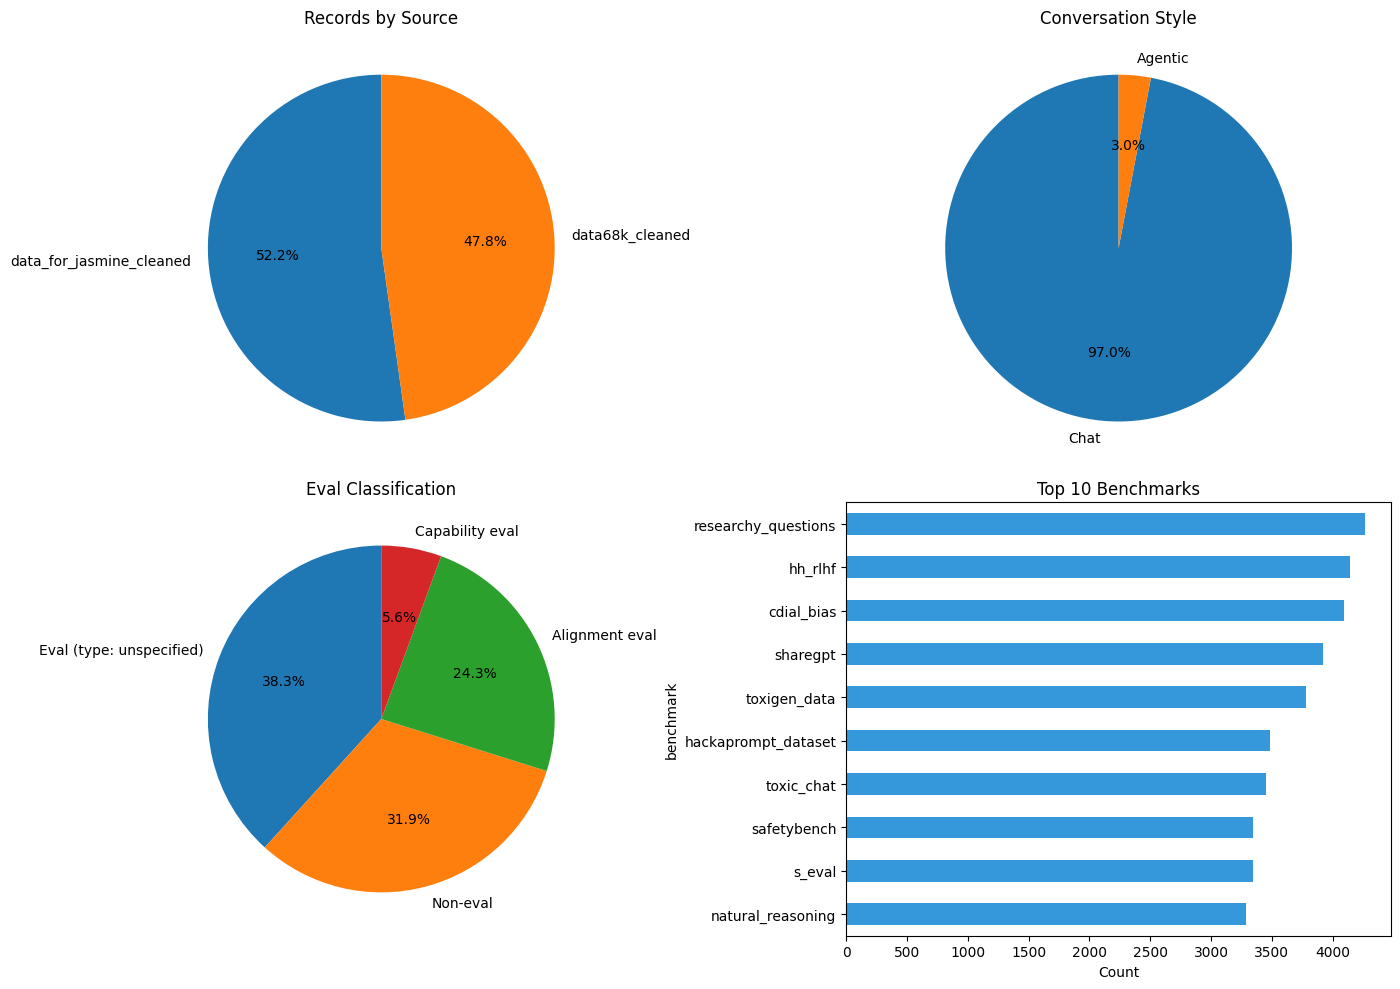

In [59]:
# Visualize overall summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Source distribution
ax1 = axes[0, 0]
source_counts.plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=90)
ax1.set_title('Records by Source')
ax1.set_ylabel('')

# Conversation style
ax2 = axes[0, 1]
style_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Conversation Style')
ax2.set_ylabel('')

# Eval classification
ax3 = axes[1, 0]
eval_class_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Eval Classification')
ax3.set_ylabel('')

# Top 10 benchmarks
ax4 = axes[1, 1]
benchmark_counts.head(10).plot(kind='barh', ax=ax4, color='#3498db')
ax4.set_title('Top 10 Benchmarks')
ax4.set_xlabel('Count')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Data Quality Check

In [60]:
print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Check for empty inputs
empty_inputs = sum(1 for item in data_combined if not item.get('input', []))
print(f"\n1. Empty inputs: {empty_inputs}")

# Check for duplicate IDs
id_counts = Counter(item.get('id') for item in data_combined)
duplicates = {id_: count for id_, count in id_counts.items() if count > 1}
print(f"2. Duplicate IDs: {len(duplicates)}")

# Check for messages with empty content
empty_content_count = 0
for item in data_combined:
    for msg in item.get('input', []):
        if isinstance(msg.get('content', ''), str) and len(msg.get('content', '')) == 0:
            empty_content_count += 1
print(f"3. Messages with empty content: {empty_content_count}")

# Message count statistics
print(f"\n4. Message count statistics:")
print(df['num_messages'].describe())

DATA QUALITY CHECK

1. Empty inputs: 0
2. Duplicate IDs: 0
3. Messages with empty content: 25243

4. Message count statistics:
count    90576.000000
mean         3.599739
std          7.222997
min          2.000000
25%          2.000000
50%          2.000000
75%          2.000000
max        114.000000
Name: num_messages, dtype: float64
